In [1]:
# adiciona a raiz do repo no sys.path (funciona no VS Code e no Colab)
from pathlib import Path
import sys


repo_root = Path().resolve()
while repo_root != repo_root.parent and not (repo_root / "src").exists():
    repo_root = repo_root.parent
if (repo_root / "src").exists():
    sys.path.insert(0, str(repo_root))
else:
    raise RuntimeError("Não encontrei a pasta 'src' acima do diretório atual.")


In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from src.models.mlp_activations import select_mlp_activations
from src.pixel_preprocessing import (
    prepare_pixel_data,
    standardize_bands,
    apply_pca
)
from keras.models import Sequential
from keras.layers import Dense, Input, Flatten
import tensorflow as tf
import pandas as pd
import numpy as np
import json
import re
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


&emsp;Os hiperparâmetros do modelo foram definidos priorizando estabilidade, capacidade de generalização e baixo custo computacional. A taxa de aprendizado foi fixada em 0,001, valor padrão recomendado para o otimizador Adam, que proporciona convergência estável e evita oscilações grandes durante o treinamento; valores maiores poderiam gerar instabilidade, enquanto valores menores tornariam o processo mais lento. O otimizador escolhido foi o Adam (Adaptive Moment Estimation), devido à sua capacidade de combinar as vantagens do Momentum e do RMSProp, ajustando automaticamente a taxa de aprendizado para cada parâmetro, resultando em convergência rápida e robusta, sendo amplamente utilizado como referência em redes neurais. O tamanho do lote (batch size) foi definido como 32, equilibrando estabilidade na atualização dos gradientes e custo computacional, além de reduzir o ruído nas atualizações em comparação a batches muito pequenos. O modelo foi treinado por 100 épocas, número suficiente para permitir que a rede convergisse sem overfitting inicial, podendo ser ajustado posteriormente com técnicas como Early Stopping se necessário. Veja na tabela a seguir os hiperparâmetros definidos:


  <strong>Tabela  1</strong> – Hiperparâmetros definidos


| Hiperparâmetro                       | Valor Definido                                  | Justificativa                                           |
| ------------------------------------ | ----------------------------------------------- | ------------------------------------------------------- |
| Taxa de aprendizado (learning rate)  | 0.001                                           | Valor padrão estável para otimizadores adaptativos      |
| Otimizador                           | Adam                                            | Convergência rápida e robusta                           |
| Batch size                           | 32                                              | Bom equilíbrio entre estabilidade e custo computacional |
| Número de épocas                     | 100                                             | Suficiente para convergência sem overfitting inicial    |
| Função de ativação (camadas ocultas) | ReLU                                            | Evita problema de gradiente desaparecendo               |
| Função de ativação (saída)           | Sigmoid                          | Adequado para classificação binária                          |
| Função de perda                      | Binary Crossentropy  | Adequado para classificação binária                     |
| Número de camadas ocultas            |  2                                          | Arquitetura simples para baseline                       |
| Número de neurônios                  | 64                                      | Capacidade suficiente sem excesso de complexidade       |
<p style="font-size: 0.9em;">Fonte: Elaboração própria.</p>



&emsp;A arquitetura escolhida é simples, com duas camadas ocultas contendo 64 neurônios na primeira camada e 32 na segunda , garantindo capacidade de modelar relações não-lineares enquanto mantém baixo risco de overfitting e custo computacional reduzido. Para as camadas ocultas, a função de ativação adotada foi a ReLU, que evita o problema de gradientes desaparecendo e acelera o treinamento, sendo padrão em redes densas. Para a camada de saída, utilizou-se Sigmoid como função de saída, por ser mais adequada para probelmas de classificação binária. A função de perda escolhida foi Binary Crossentropy, também considerando o tipo de classificação.


In [3]:
def load_dataset_with_groups(dataset_path: Path, codes_path: Path):

    if not dataset_path.exists():
        raise FileNotFoundError(f"Dataset nao encontrado: {dataset_path}")

    if not codes_path.exists():
        raise FileNotFoundError(f"Arquivo de codigos nao encontrado: {codes_path}")

    df = pd.read_csv(dataset_path)

    with open(codes_path, "r", encoding="utf-8") as f:
        codes = json.load(f)

    positivos = set(codes.get("positivos", []))
    negativos = set(codes.get("negativos", []))

    all_ids = sorted(list(positivos | negativos), key=len, reverse=True)
    pattern = "|".join(re.escape(v) for v in all_ids)

    df["image_id"] = df["path"].astype(str).str.extract(rf"({pattern})", expand=False)

    def map_label(img_id):
        if img_id in positivos:
            return 1
        if img_id in negativos:
            return 0
        return np.nan

    df["label"] = df["image_id"].map(map_label)
    df = df.dropna(subset=["image_id", "label"]).copy()
    df["label"] = df["label"].astype(int)

    feature_cols = [c for c in df.columns if c.startswith("pixel_")]

    return df, feature_cols

In [4]:

DATASET_PATH = repo_root / "data" / "pixels_dataset.csv"
CODES_PATH = repo_root / "data" / "extracted_codes.json"
OUTPUT_DIR = repo_root / "outputs" / "a03_mlp_baseline"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repositorio: {repo_root}")
print(f"Dataset: {DATASET_PATH}")
print(f"Codigos: {CODES_PATH}")
print(f"Saida: {OUTPUT_DIR}")

Repositorio: /Users/pedroauler/Developer/inteli/inteliM9/g01
Dataset: /Users/pedroauler/Developer/inteli/inteliM9/g01/data/pixels_dataset.csv
Codigos: /Users/pedroauler/Developer/inteli/inteliM9/g01/data/extracted_codes.json
Saida: /Users/pedroauler/Developer/inteli/inteliM9/g01/outputs/a03_mlp_baseline


### Carregamento do dataset e definição das features
- **Objetivo:** carregar os dados e preparar as variáveis base para o pipeline.
- **Entrada:** `DATASET_PATH` (CSV de pixels) e `CODES_PATH` (JSON com positivos/negativos).
- **Processo:** aplica `load_dataset_with_groups`, que cria `image_id`, mapeia `label` e identifica as colunas `pixel_*`.
- **Saída:** `df_all` (dados completos) e `feature_cols` (lista de features), além de prints de conferência.

In [5]:
df_all, feature_cols = load_dataset_with_groups(
    DATASET_PATH,
    CODES_PATH
)

print("Dataset carregado:", df_all.shape)
print("Número de features:", len(feature_cols))

Dataset carregado: (295, 147466)
Número de features: 147456


###Checagem a estrutura dos pixels

In [6]:
n_pixels = len(feature_cols)
n_bands = 9

pixels_per_band = n_pixels // n_bands
side = int(np.sqrt(pixels_per_band))

print("Total colunas pixel:", n_pixels)
print("Pixels por banda:", pixels_per_band)
print("Dimensão estimada:", side, "x", side)

Total colunas pixel: 147456
Pixels por banda: 16384
Dimensão estimada: 128 x 128


### Divide os dados em treino e teste e validaçao

In [7]:
SEED = 42

image_level = df_all[["image_id", "label"]].drop_duplicates()

train_val_ids, test_ids = train_test_split(
    image_level["image_id"],
    test_size=0.20,
    random_state=SEED,
    stratify=image_level["label"],
)

train_val_df = image_level[image_level["image_id"].isin(train_val_ids)]

train_ids, val_ids = train_test_split(
    train_val_df["image_id"],
    test_size=0.25,
    random_state=SEED,
    stratify=train_val_df["label"],
)

df_train = df_all[df_all["image_id"].isin(train_ids)].copy()
df_val   = df_all[df_all["image_id"].isin(val_ids)].copy()
df_test  = df_all[df_all["image_id"].isin(test_ids)].copy()

In [8]:
band_cols = feature_cols  # suas 147456 colunas

def compute_band_means(df, n_bands=9):
    n_pixels = len(band_cols)
    pixels_per_band = n_pixels // n_bands
    
    X = df[band_cols].values
    X = X.reshape(len(df), n_bands, pixels_per_band)
    
    band_means = X.mean(axis=2)  # média por banda
    
    columns = [f"B{i+1:02d}" for i in range(n_bands)]
    df_means = pd.DataFrame(band_means, columns=columns)
    df_means["label"] = df["label"].values
    
    return df_means

df_train_spec = compute_band_means(df_train)
df_val_spec   = compute_band_means(df_val)
df_test_spec  = compute_band_means(df_test)

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(df_train_spec.drop(columns="label"))
X_val   = scaler.transform(df_val_spec.drop(columns="label"))
X_test  = scaler.transform(df_test_spec.drop(columns="label"))

y_train = df_train_spec["label"].values
y_val   = df_val_spec["label"].values
y_test  = df_test_spec["label"].values

In [10]:
pca = PCA(n_components=0.95, random_state=SEED)

X_train_pca = pca.fit_transform(X_train)
X_val_pca   = pca.transform(X_val)
X_test_pca  = pca.transform(X_test)

print("Componentes finais:", pca.n_components_)

Componentes finais: 2


In [11]:
INPUT_SHAPE = (X_train_pca.shape[1],)

In [12]:
TASK_TYPE = "classification"
N_CLASSES = 2   # alterar para >2 caso multiclasse

In [13]:
activation_config = select_mlp_activations(
    task_type=TASK_TYPE,
    n_classes=N_CLASSES
)

hidden_activation = activation_config["hidden_activation"]
output_activation = activation_config["output_activation"]

print("Configuração selecionada:")
print(activation_config)

Configuração selecionada:
{'hidden_activation': 'relu', 'hidden_justification': 'ReLU nas camadas ocultas acelera o treinamento e reduz saturacao de gradiente em comparacao com Sigmoid.', 'output_activation': 'sigmoid', 'output_justification': 'Sigmoid na saida e adequada para classificacao binaria, produzindo probabilidade no intervalo [0, 1].'}


In [14]:
from tensorflow.keras import regularizers

def build_mlp(input_shape, n_classes, hidden_activation, output_activation):

    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Dense(
            64,
            activation=hidden_activation,
            kernel_regularizer=regularizers.l2(0.001)
        ),
        layers.Dropout(0.3),

        layers.Dense(
            32,
            activation=hidden_activation,
            kernel_regularizer=regularizers.l2(0.001)
        ),
        layers.Dropout(0.3),

        layers.Dense(
            1 if n_classes == 2 else n_classes,
            activation=output_activation
        )
    ])

    return model

In [15]:
model = build_mlp(
    input_shape=INPUT_SHAPE,
    n_classes=N_CLASSES,
    hidden_activation=hidden_activation,
    output_activation=output_activation
)

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305 (9.00 KB)

 Trainable params: 2,305 (9.00 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

if N_CLASSES == 2:
    loss_fn = "binary_crossentropy"
    metrics = [
        "accuracy",
        tf.keras.metrics.AUC(name="auc_roc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
else:
    loss_fn = "sparse_categorical_crossentropy"
    metrics = [
        "accuracy",
        tf.keras.metrics.AUC(name="auc_roc", multi_label=True)
    ]

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=metrics
)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [19]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Model input shape:", model.input_shape)
print("Número de classes:", len(np.unique(y_train)))

X_train shape: (177, 9)
y_train shape: (177,)
Model input shape: (None, 2)
Número de classes: 2


In [20]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Model input shape:", model.input_shape)
print("Número de classes:", len(np.unique(y_train)))

X_train shape: (177, 9)
y_train shape: (177,)
Model input shape: (None, 2)
Número de classes: 2


In [21]:
from tensorflow.keras.backend import clear_session
clear_session()

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np

INPUT_SHAPE = (X_train.shape[1],)

model = Sequential([
    Dense(32, activation='relu', input_shape=INPUT_SHAPE),
    Dense(16, activation='relu'),
    Dense(2, activation='sigmoid')  # 2 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/Users/pedroauler/miniforge3/envs/aster/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
print("Model input shape:", model.input_shape)

Model input shape: (None, 9)


In [24]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.5819 - loss: 0.7401 - val_accuracy: 0.6271 - val_loss: 0.7341
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6328 - loss: 0.6630 - val_accuracy: 0.6271 - val_loss: 0.6773
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6384 - loss: 0.6129 - val_accuracy: 0.6271 - val_loss: 0.6429
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6271 - loss: 0.5821 - val_accuracy: 0.6610 - val_loss: 0.6193
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7571 - loss: 0.5569 - val_accuracy: 0.7119 - val_loss: 0.6036
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7797 - loss: 0.5378 - val_accuracy: 0.7458 - val_loss: 0.5942
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7797 - loss: 0.5282 - val_accuracy: 0.7627 - val_loss: 0.5871
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7797 - loss: 0.5181 - val_accuracy: 0.7627 - val_loss: 0.5819

In [25]:
## Avaliação final no conjunto de teste 
test_results = model.evaluate(X_test, y_test, verbose=0)
#print
print("Resultados no teste:")
for name, value in zip(model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")


Resultados no teste:
loss: 0.3597
compile_metrics: 0.8136


In [26]:
y_prob = model.predict(X_test) 
# Ele olha qual das colunas tem o maior número e pega o índice dela
y_pred = np.argmax(y_prob, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [27]:
#matriz de confusão
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, y_pred)
print("Matriz de Confusão:")
print(cm)

Matriz de Confusão:
[[31  5]
 [ 6 17]]


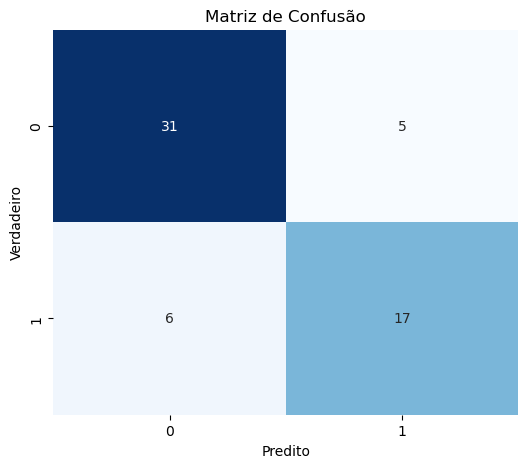

In [28]:
# Gerar gráfico da matriz de confusão em forma de heatmap 
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predito")
plt.ylabel("Verdadeiro")
plt.title("Matriz de Confusão")
plt.show()

In [29]:
#Calcular accuracy, precision, recall, f1-score
report = classification_report(y_test, y_pred, target_names=["Negativo", "Positivo"])
print("Relatório de Classificação:")
print(report)


Relatório de Classificação:
              precision    recall  f1-score   support

    Negativo       0.84      0.86      0.85        36
    Positivo       0.77      0.74      0.76        23

    accuracy                           0.81        59
   macro avg       0.81      0.80      0.80        59
weighted avg       0.81      0.81      0.81        59



In [30]:
#calculo de AUC-ROC
from sklearn.metrics import roc_auc_score
auc_roc = roc_auc_score(y_test, y_prob[:, 1])  # probabilidade da classe positiva
print(f"AUC-ROC: {auc_roc:.4f}")

AUC-ROC: 0.9136


In [31]:
# salvar modelo treinado e métricas 
model.save(OUTPUT_DIR / "mlp_baseline_model_S2.keras")
#salvar métricas em .json
metrics_dict = dict(zip(model.metrics_names, test_results))
with open(OUTPUT_DIR / "mlp_baseline_metrics.json", "w") as f:
    json.dump(metrics_dict, f, indent=4)

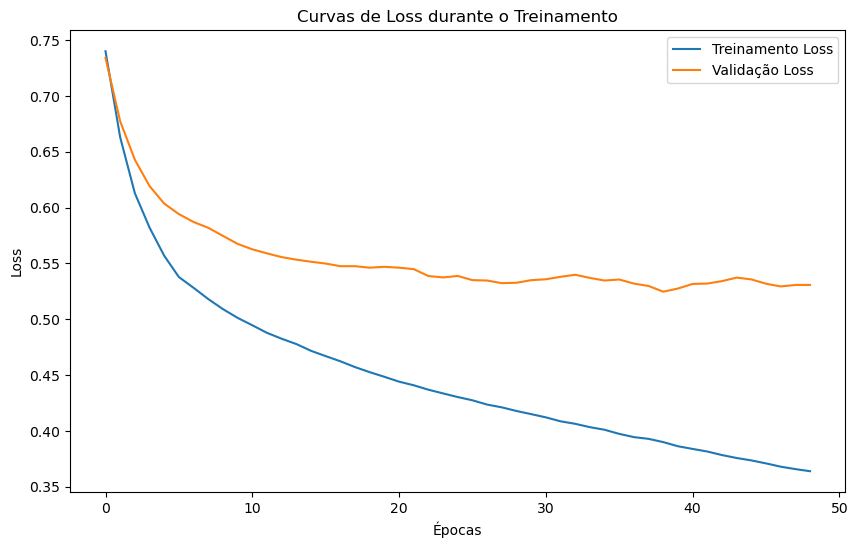

In [32]:
#plotar curvas de treinamento e validação loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Treinamento Loss')
plt.plot(history.history['val_loss'], label='Validação Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.title('Curvas de Loss durante o Treinamento')
plt.legend()
plt.show()

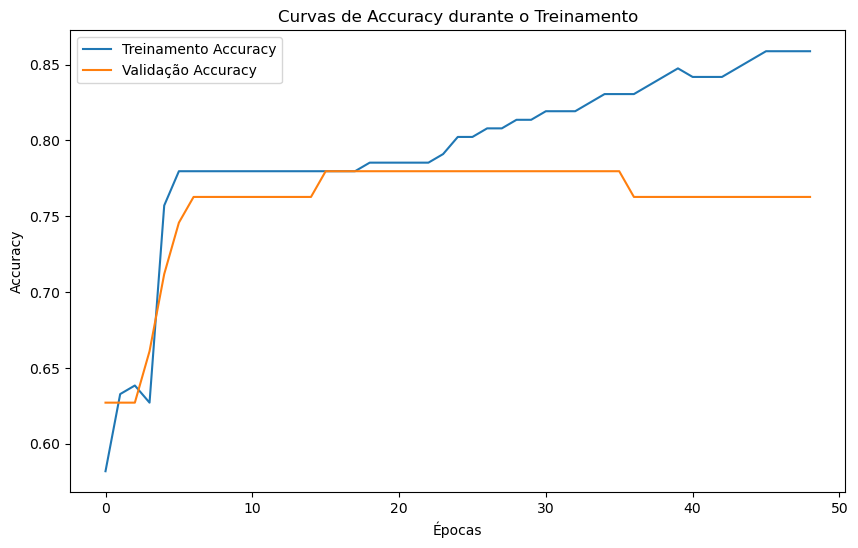

In [33]:
#plotar curvas de treinamento e validação accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Treinamento Accuracy')
plt.plot(history.history['val_accuracy'], label='Validação Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.title('Curvas de Accuracy durante o Treinamento')
plt.legend()
plt.show()

Tabela de tempo de treino e inferencia

In [34]:
import time

t0 = time.perf_counter()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)
train_time_s = time.perf_counter() - t0
print(f"Tempo de treino (s): {train_time_s:.2f}")

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8475 - loss: 0.3865 - val_accuracy: 0.7627 - val_loss: 0.5258
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8475 - loss: 0.3839 - val_accuracy: 0.7627 - val_loss: 0.5287
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8475 - loss: 0.3812 - val_accuracy: 0.7627 - val_loss: 0.5302
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8418 - loss: 0.3793 - val_accuracy: 0.7627 - val_loss: 0.5359
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8475 - loss: 0.3775 - val_accuracy: 0.7627 - val_loss: 0.5376
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8531 - loss: 0.3741 - val_accuracy: 0.7627 - val_loss: 0.5286
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8531 - loss: 0.3720 - val_accuracy: 0.7627 - val_loss: 0.5260
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8531 - loss: 0.3706 - val_accuracy: 0.7627 - val_loss: 0.524

In [35]:
t0 = time.perf_counter()
_ = model.predict(X_test, verbose=0)
infer_time_s = time.perf_counter() - t0
infer_time_ms_por_amostra = (infer_time_s / len(X_test)) * 1000

print(f"Tempo de inferência total (s): {infer_time_s:.4f}")
print(f"Tempo médio por amostra (ms): {infer_time_ms_por_amostra:.4f}")

Tempo de inferência total (s): 0.0552
Tempo médio por amostra (ms): 0.9352


In [ ]:
import pandas as pd

df_tempos = pd.DataFrame([
    {"etapa": "treino", "tempo_s": train_time_s, "amostras": len(X_train), "tempo_ms_por_amostra": (train_time_s/len(X_train))*1000},
    {"etapa": "inferencia_teste", "tempo_s": infer_time_s, "amostras": len(X_test), "tempo_ms_por_amostra": infer_time_ms_por_amostra},
])

display(df_tempos)
df_tempos.to_csv(OUTPUT_DIR / "tempos_treino_inferencia.csv", index=False)

,etapa,tempo_s,amostras,tempo_ms_por_amostra
0,treino,1.796755,177,10.151158
1,inferencia_teste,0.055176,59,0.935195


### Analise das Features

In [46]:

from pathlib import Path
from sklearn.metrics import roc_auc_score, accuracy_score

In [47]:
# Se existir df_test_spec, usa os nomes reais das bandas (B01..B09)
if "df_test_spec" in globals():
    feature_names = list(df_test_spec.drop(columns="label").columns)
else:
    feature_names = [f"f{i}" for i in range(X_test.shape[1])]

X_eval = X_test.copy()
y_eval = y_test.copy()

print("Features usadas:", feature_names)
print("Shape X_eval:", X_eval.shape)
print("Shape y_eval:", y_eval.shape)

Features usadas: ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09']
Shape X_eval: (59, 9)
Shape y_eval: (59,)


In [48]:
def get_model_outputs(model, X):
    y_prob = model.predict(X, verbose=0)
    if y_prob.ndim == 1:
        y_score = y_prob
        y_pred = (y_score >= 0.5).astype(int)
    elif y_prob.shape[1] == 1:
        y_score = y_prob[:, 0]
        y_pred = (y_score >= 0.5).astype(int)
    else:
        y_score = y_prob[:, 1]  # probabilidade da classe positiva
        y_pred = np.argmax(y_prob, axis=1)
    return y_score, y_pred

def evaluate_metric(model, X, y, metric="auc"):
    y_score, y_pred = get_model_outputs(model, X)
    if metric == "auc":
        return roc_auc_score(y, y_score)
    if metric == "accuracy":
        return accuracy_score(y, y_pred)
    raise ValueError("Métrica inválida. Use 'auc' ou 'accuracy'.")

In [49]:
metric_name = "auc"   # pode trocar para "accuracy"
baseline_score = evaluate_metric(model, X_eval, y_eval, metric=metric_name)
print(f"Baseline ({metric_name}): {baseline_score:.4f}")

Baseline (auc): 0.9143


In [50]:
rng = np.random.default_rng(42)
n_repeats = 20

importances = np.zeros((X_eval.shape[1], n_repeats), dtype=float)

for j in range(X_eval.shape[1]):
    X_perm = X_eval.copy()
    for r in range(n_repeats):
        idx = rng.permutation(X_perm.shape[0])
        X_perm[:, j] = X_eval[idx, j]
        perm_score = evaluate_metric(model, X_perm, y_eval, metric=metric_name)
        importances[j, r] = baseline_score - perm_score  # queda da métrica

In [52]:
importance_mean = importances.mean(axis=1)
importance_std = importances.std(axis=1)

df_importance = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": importance_mean,
    "importance_std": importance_std
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

print("Top features:")
display(df_importance)

Top features:


,feature,importance_mean,importance_std
0,B09,0.274094,0.088153
1,B02,0.166002,0.053461
2,B08,0.160568,0.055385
3,B01,0.136292,0.053343
4,B06,0.105254,0.035764
5,B03,0.087983,0.040363
6,B07,0.062742,0.037096
7,B04,0.034541,0.022817
8,B05,0.018237,0.021802


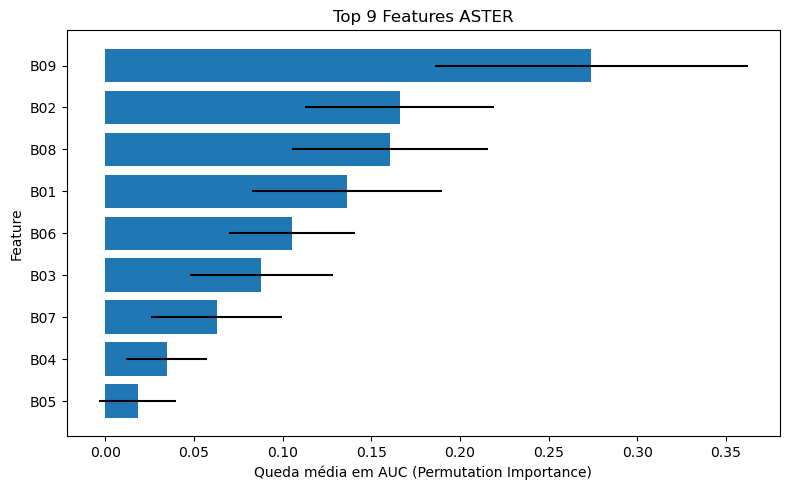

In [55]:
top_n = min(10, len(df_importance))
df_top = df_importance.head(top_n).iloc[::-1]

plt.figure(figsize=(8, 5))
plt.barh(
    df_top["feature"],
    df_top["importance_mean"],
    xerr=df_top["importance_std"],
)
plt.xlabel(f"Queda média em {metric_name.upper()} (Permutation Importance)")
plt.ylabel("Feature")
plt.title(f"Top {top_n} Features ASTER")
plt.tight_layout()
plt.show()

In [56]:
out_dir = OUTPUT_DIR / "feature_importance"
out_dir.mkdir(parents=True, exist_ok=True)

csv_path = out_dir / "feature_importance_permutation.csv"
png_path = out_dir / "feature_importance_permutation.png"

df_importance.to_csv(csv_path, index=False)

# salva o último gráfico exibido
plt.figure(figsize=(8, 5))
plt.barh(
    df_top["feature"],
    df_top["importance_mean"],
    xerr=df_top["importance_std"],
)
plt.xlabel(f"Queda média em {metric_name.upper()} (Permutation Importance)")
plt.ylabel("Feature")
plt.title(f"Top {top_n} Features ASTER")
plt.tight_layout()
plt.savefig(png_path, dpi=150)
plt.close()

print("CSV salvo em:", csv_path)
print("PNG salvo em:", png_path)

CSV salvo em: /Users/pedroauler/Developer/inteli/inteliM9/g01/outputs/a03_mlp_baseline/feature_importance/feature_importance_permutation.csv
PNG salvo em: /Users/pedroauler/Developer/inteli/inteliM9/g01/outputs/a03_mlp_baseline/feature_importance/feature_importance_permutation.png
